In [1]:
!pip install protobuf==3.20.3 --force-reinstall

import os
import pickle
import numpy as np
from tqdm.notebook import tqdm

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.layers import Input,Dense,LSTM,Embedding,Dropout,add

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.3 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
tens

2025-12-02 02:27:34.847287: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764642455.030971      88 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764642455.080064      88 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
Base_dir = "/kaggle/input/flickr8k"
Working_dir = "/kaggle/working/"

In [3]:
model = VGG16()

model = Model(inputs = model.inputs,outputs = model.layers[-2].output)

print(model.summary())

I0000 00:00:1764642476.119219      88 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764642476.119834      88 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

None


In [4]:
features = {}
directory = os.path.join(Base_dir,"Images")

for img_name in tqdm(os.listdir(directory)):
    
    #concatenate image and image name
    imagepath = directory+ "/" +img_name
    
    #set the size or dimension of the image
    image = load_img(imagepath,target_size = (224,224))
    
    #convert image pixel into numpy array
    image = img_to_array(image)

    #reshape the image 
    image = image.reshape((1,image.shape[0],image.shape[1],image.shape[2]))
    #image to vgg
    image = preprocess_input(image)
    #extract feature
    feature = model.predict(image,verbose = 0)
    #get image id
    image_id = img_name.split(".")[0]
    #store feature
    features[image_id] = feature

  0%|          | 0/8091 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
I0000 00:00:1764642492.828622     148 service.cc:148] XLA service 0x7c4130005760 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764642492.829292     148 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764642492.829311     148 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1764642492.959180     148 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1764642495.323692     148 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [5]:
pickle.dump(features, open(os.path.join(Working_dir,"features.pkl"),"wb"))

In [6]:
with open(os.path.join(Working_dir,"features.pkl"),"rb") as f:
    features = pickle.load(f)
print(f"Number of extracted features: {len(features)}")

Number of extracted features: 8091


In [7]:
with open(os.path.join(Base_dir,"captions.txt"),"r") as f:
    next(f)

    captions_lines = [line.strip() for line in f]
            
    # Combine the lines into a single string if needed, otherwise use the list.
    # We'll keep it as a list for easier processing later.
    captions_doc = "\n".join(captions_lines)


In [8]:
mapping = {}

for line in tqdm(captions_doc.split("\n")):
    tokens = line.split(",")
    if len(line) < 2:
        continue
    image_id,caption = tokens[0],tokens[1:]
    #remove extension from image id
    image_id = image_id.split(".")[0]
    #caption list into String
    cation = " ".join(caption)
    if image_id not in mapping:
        mapping[image_id] = []
    #store caption
    mapping[image_id].append(cation)
len(mapping)

  0%|          | 0/40455 [00:00<?, ?it/s]

8091

In [9]:
def clean(mapping):
    for key,captions in mapping.items():
        for i in range(len(captions)):
            #take one caption at a time
            caption = captions[i]
            #preprocessing steps
            #convert to lower case
            caption = [c.lower() for c in caption if isinstance(c, str)] if isinstance(caption, list) else caption.lower()
            #delete digits, special charater,etc..
            caption = [c.replace("[^A-Za-z]", "") for c in caption] if isinstance(caption, list) else caption.replace("[^A-Za-z]", "")
            #delete additional spaces
            caption = [c.replace("/s+", " ") for c in caption] if isinstance(caption, list) else caption.replace("/s+", " ")
            #add start and end tags to the capiton
            if isinstance(caption, list):
                caption = ["<start>" + " ".join([word for word in c.split() if len(word)>1]) + "<end>" for c in caption]
            else:
                caption = "<start>" + " ".join([word for word in caption.split() if len(word)>1]) + "<end>"
            captions[i] = caption  # Fixed: captions[i], not caption[i]

In [10]:
#before preprocess of text
mapping["1000268201_693b08cb0e"]

['A child in a pink dress is climbing up a set of stairs in an entry way .',
 'A girl going into a wooden building .',
 'A little girl climbing into a wooden playhouse .',
 'A little girl climbing the stairs to her playhouse .',
 'A little girl in a pink dress going into a wooden cabin .']

In [11]:
#preprocessing the text
clean(mapping)

In [12]:
mapping["1000268201_693b08cb0e"]

['<start>child in pink dress is climbing up set of stairs in an entry way<end>',
 '<start>girl going into wooden building<end>',
 '<start>little girl climbing into wooden playhouse<end>',
 '<start>little girl climbing the stairs to her playhouse<end>',
 '<start>little girl in pink dress going into wooden cabin<end>']

In [13]:
all_captions = []
for key in mapping:
    for caption in mapping[key]:
        all_captions.append(caption)

In [14]:
len(all_captions)

40455

In [15]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1

In [16]:
vocab_size

8483

In [17]:
##train test split 
image_ids = list(set(mapping.keys()))
split = int(len(image_ids) * 0.90)
train = image_ids[:split]
test = image_ids[split:]

In [18]:
# Get maximum len of the caption available (handling nested lists)
max_length = max(
    len(c.split()) 
    for caption in all_captions 
    for c in (caption if isinstance(caption, list) else [caption]) 
    if isinstance(c, str)
)
print(max_length)

33


In [19]:
#['A girl going into a wooden building .']
#               x                   y
#<start>                            girl
#<start>girl                        going
#<start>girl going                  into
#................
#<start>girl going into wooden building<end>

In [37]:
def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    X1, X2, y = [], [], []

    while True:
        for key in data_keys:

            img_feature = features[key].squeeze()     # <<< FIXED HERE
            captions = mapping[key]

            for caption in captions:

                seq = tokenizer.texts_to_sequences([caption])[0]

                for i in range(1, len(seq)):
                    in_seq = seq[:i]
                    out_seq = seq[i]

                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                    out_seq = to_categorical(out_seq, num_classes=vocab_size)

                    X1.append(img_feature)
                    X2.append(in_seq)
                    y.append(out_seq)

                    if len(X1) == batch_size:
                        yield (np.array(X1), np.array(X2)), np.array(y)
                        X1, X2, y = [], [], []


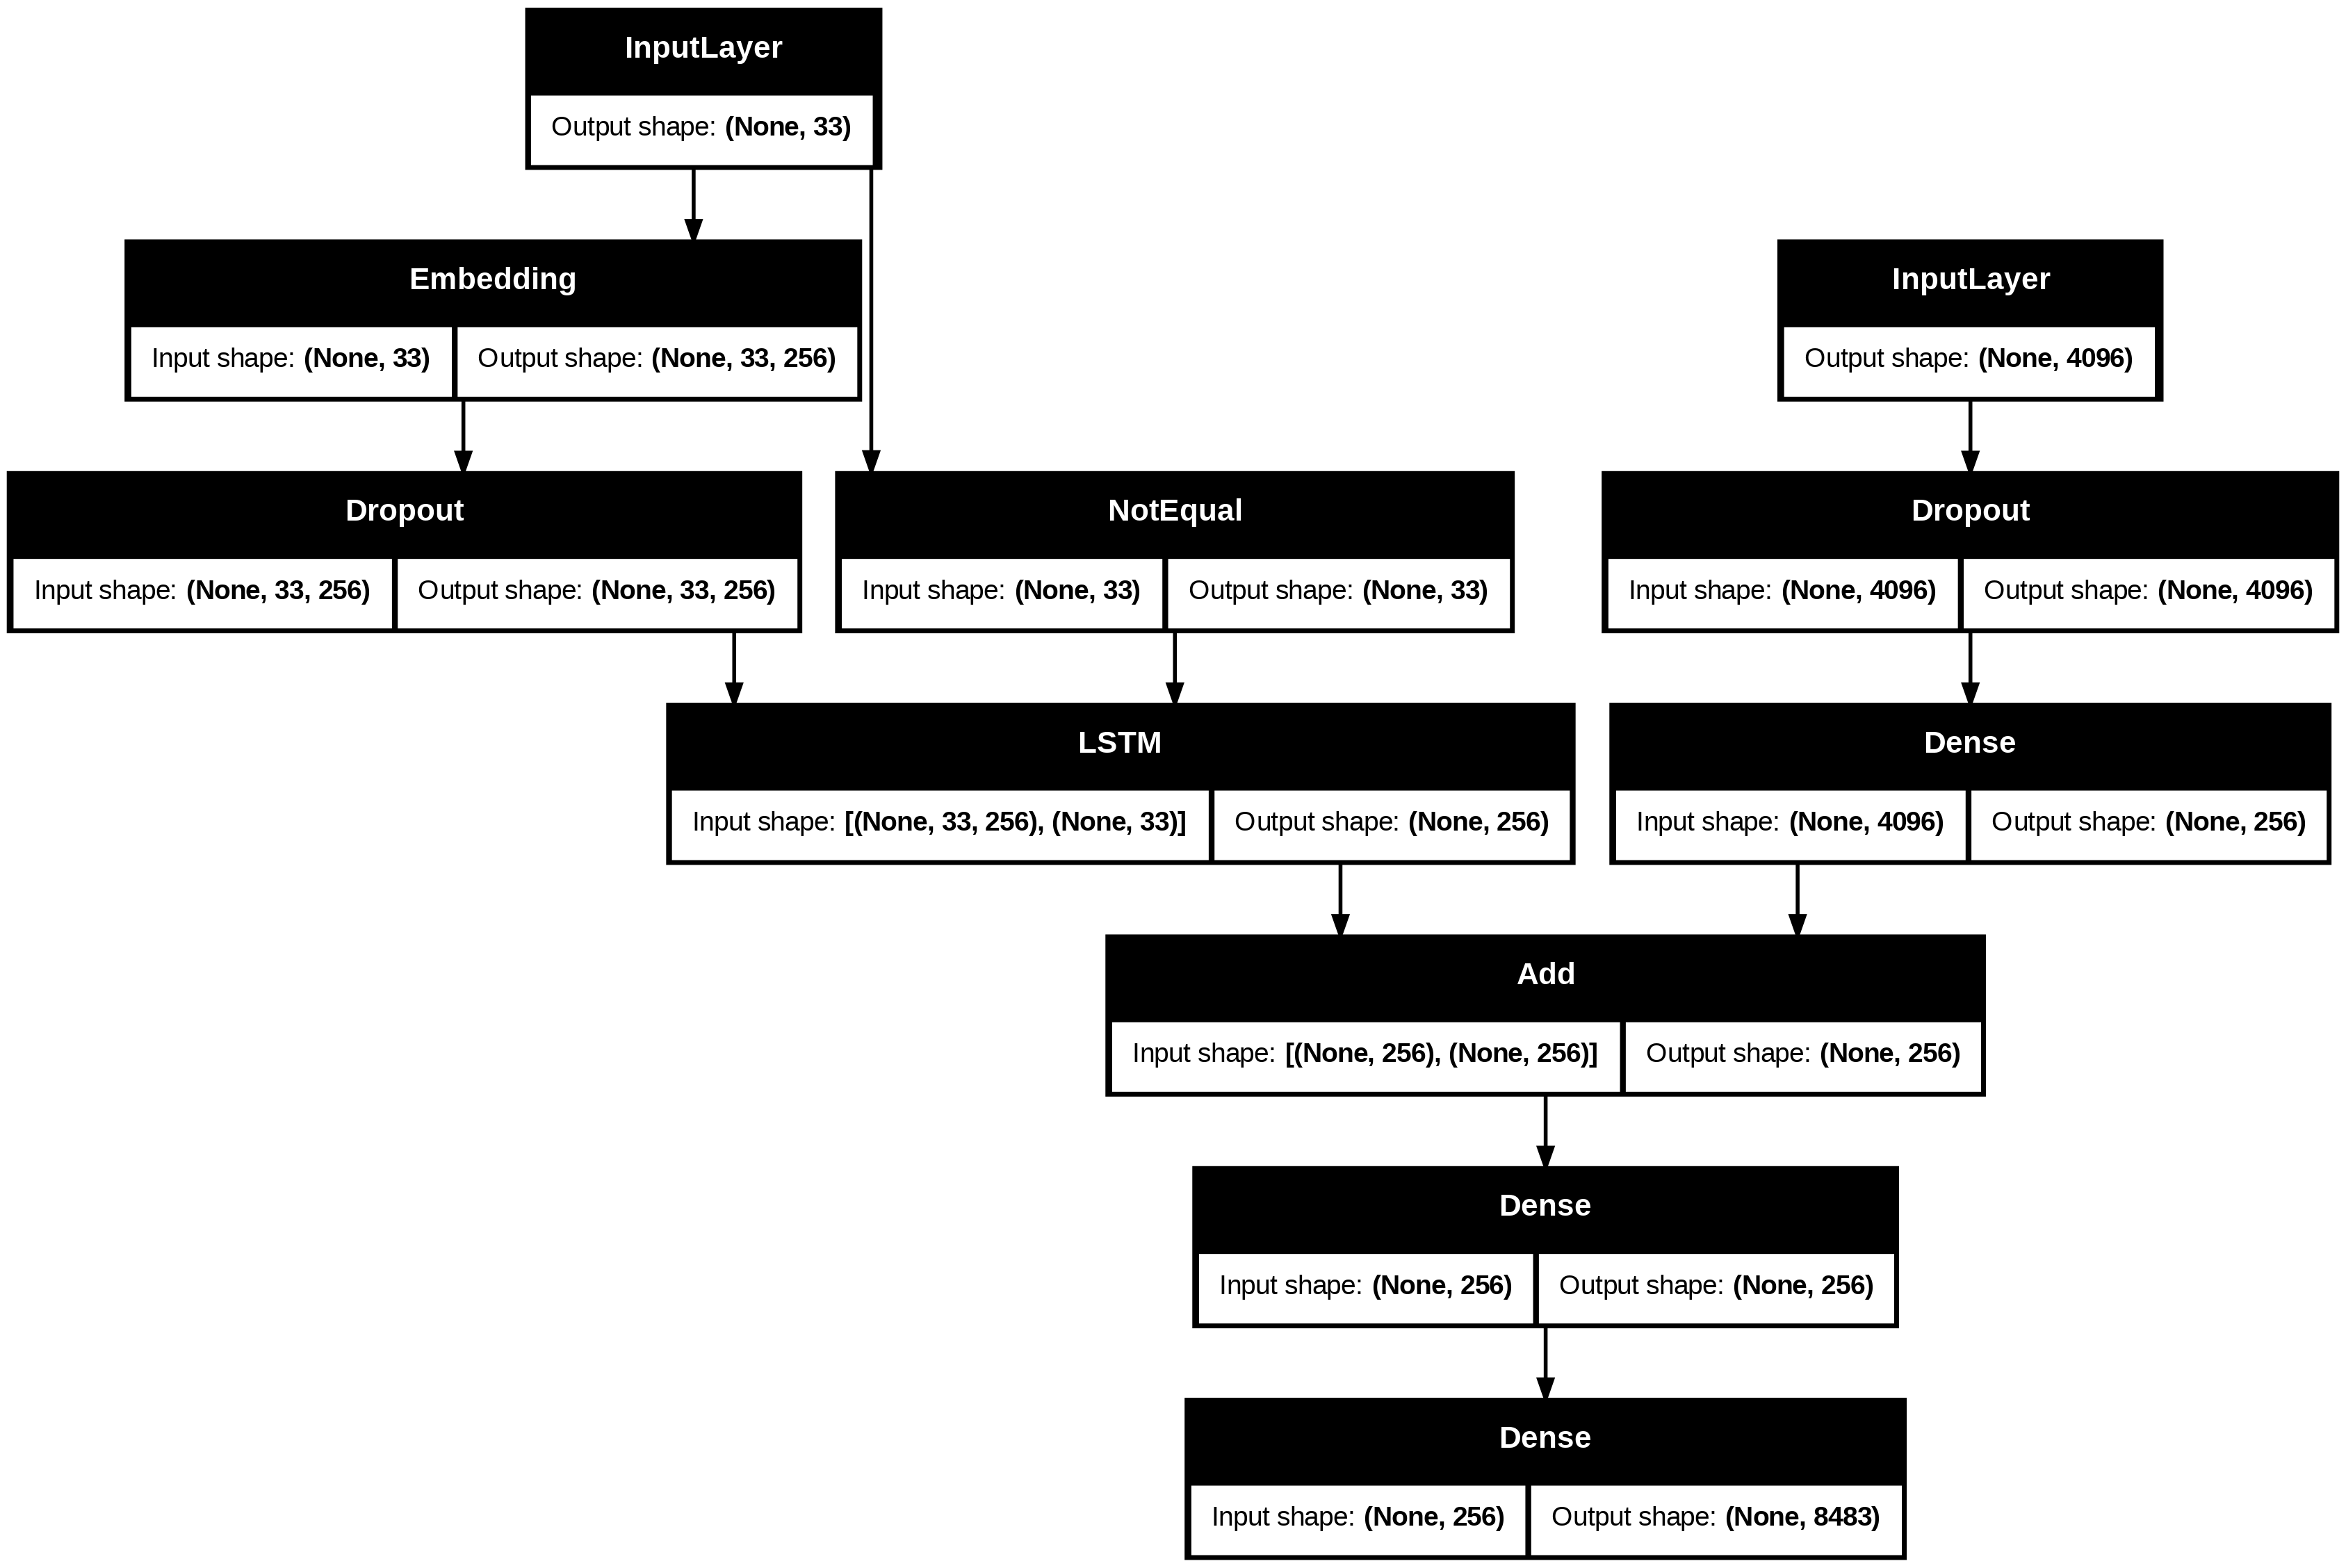

In [38]:
# MODEL CREATION

# Image feature model
inputs1 = Input(shape=(4096,))
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation="relu")(fe1)

# Sequence feature model
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.4)(se1)
se3 = LSTM(256, use_cudnn=False)(se2)   # <-- FIXED HERE

# Decoder
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation="softmax")(decoder2)

model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss="categorical_crossentropy", optimizer="adam")

plot_model(model, show_shapes = True)

In [39]:
#train the model
epochs = 30
batch_size = 64
steps = len(train) // batch_size
for i in tqdm(range(epochs)):
    #create data generator
    generator = data_generator(train, mapping, features, tokenizer, max_length, vocab_size, batch_size)
    #fit for one epoch
    model.fit(
    generator,
    epochs=epochs,
    steps_per_epoch=steps,
    verbose=1
)


  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 7.1367
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.8370
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.5730
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.5228
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.3518
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.1809
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.0192
Epoch 8/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.0239
Epoch 9/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.9794
Epoch 10/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.8936
Epoch 11/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.9099
Epoch 12/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.9718
Epoch 13/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.6110
Epoch 14/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.5337
Epoch 15/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s

In [40]:
model.save(Working_dir+"/my_model.keras")


In [41]:
def idx_to_word(integer, tokenizer):
    for word, index in  tokenizer.word_index.items():
        if index == integer:
            return word

    return None

In [43]:
def predict_caption(model, image, tokenizer, max_length):
    in_text = "<start>"

    for i in range(max_length):
        # convert text to integer sequence
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)

        # predict next word
        yhat = model.predict([image, sequence], verbose=0)
        yhat = np.argmax(yhat)

        # map integer to word
        word = idx_to_word(yhat, tokenizer)
        if word is None:
            break

        # append word
        in_text += " " + word

        # stop if <end> predicted
        if word == "<end>":
            break

    return in_text


In [44]:
from nltk.translate.bleu_score import corpus_bleu

actual, predicted = [], []

for key in tqdm(test):

    # Actual captions
    captions = mapping[key]
    actual_captions = [
        [w for w in caption.split() if w not in ["<start>", "<end>"]]
        for caption in captions
    ]

    # Predicted caption
    y_pred = predict_caption(model, features[key], tokenizer, max_length)
    y_pred = y_pred.split()
    y_pred = [w for w in y_pred if w not in ["<start>", "<end>"]]

    actual.append(actual_captions)
    predicted.append(y_pred)

# BLEU
print("BLEU-1: %f" % corpus_bleu(actual, predicted, weights=(1, 0, 0, 0)))
print("BLEU-2: %f" % corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))
print("BLEU-3: %f" % corpus_bleu(actual, predicted, weights=(0.33, 0.33, 0.33, 0)))
print("BLEU-4: %f" % corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25)))


  0%|          | 0/810 [00:00<?, ?it/s]

BLEU-1: 0.103330
BLEU-2: 0.045222
BLEU-3: 0.021327
BLEU-4: 0.009403


In [45]:
##visualize the results

In [46]:
from PIL import Image
import matplotlib.pyplot as plt
def generator_caption(image_name):
    #load the image
    #image_name = ""#
    image_id = image_name.split(".")[0]
    image_path = os.path.join(Base_dir,'Images', image_name)
    image = Image.open(image_path)
    captions = mapping[image_id]
    print("============ACTUAL===============")
    for caption in captions:
        print(caption)
    y_pred = predict_caption(model, features[image_id], tokenizer, max_length)
    print("===============PREDICTED===============")
    print(y_pred)
    plt.imshow(image)


============ACTUAL===============
<start>black dog leaps over log<end>
<start>grey dog is leaping over fallen tree<end>
<start>large black dog leaps fallen log<end>
<start>mottled black and grey dog in blue collar jumping over fallen tree<end>
<start>the black dog jumped the tree stump<end>
===============PREDICTED===============
<start> dog is running through the grass end man in the background end look nearby end of frame end end it end it end end look nearby end end it end end look nearby


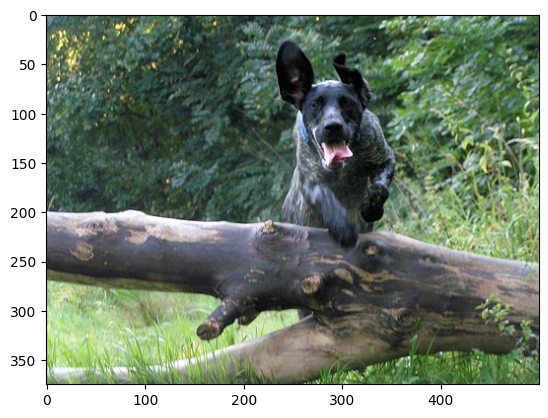

In [49]:
generator_caption("1015584366_dfcec3c85a.jpg")